# Ensemble Learning: AdaBoost Regression on the Diabetes Dataset

---

## Introduction

**AdaBoostRegressor** is a sequential ensemble method that builds a strong regressor by combining many weak learners — typically shallow decision trees. Each new learner focuses on the samples that the previous ones predicted poorly, with errors driving weight updates that redirect attention to harder examples.

This notebook applies `AdaBoostRegressor` to the **Diabetes dataset**, a standard scikit-learn regression benchmark. The dataset contains 10 physiological features measured from 442 diabetes patients, with the target being a quantitative measure of disease progression one year after baseline.

### Dataset Features

| Feature | Description |
|---|---|
| `age` | Age |
| `sex` | Sex |
| `bmi` | Body mass index |
| `bp` | Average blood pressure |
| `s1`–`s6` | Six blood serum measurements |
| `target` | Disease progression score (continuous) |

All features are pre-normalized to zero mean and unit variance in the sklearn version of the dataset.

### Workflow

1. Load and explore the dataset
2. Split into train and test sets
3. Train an `AdaBoostRegressor` and evaluate with R² and RMSE
4. Compare against a single Decision Tree baseline
5. Analyze the effect of `n_estimators` and `learning_rate`
6. Visualize feature importances and predicted vs. actual
7. Results summary

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---

## 2. Loading and Exploring the Dataset

In [2]:
data = load_diabetes()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print('Shape       :', df.shape)
print('Features    :', data.feature_names)
print('Target range: [{:.1f}, {:.1f}]'.format(y.min(), y.max()))
df.head()

Shape       : (442, 11)
Features    : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target range: [25.0, 346.0]


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
df.describe().round(3)

### 2.1 Target Distribution and Feature Correlations

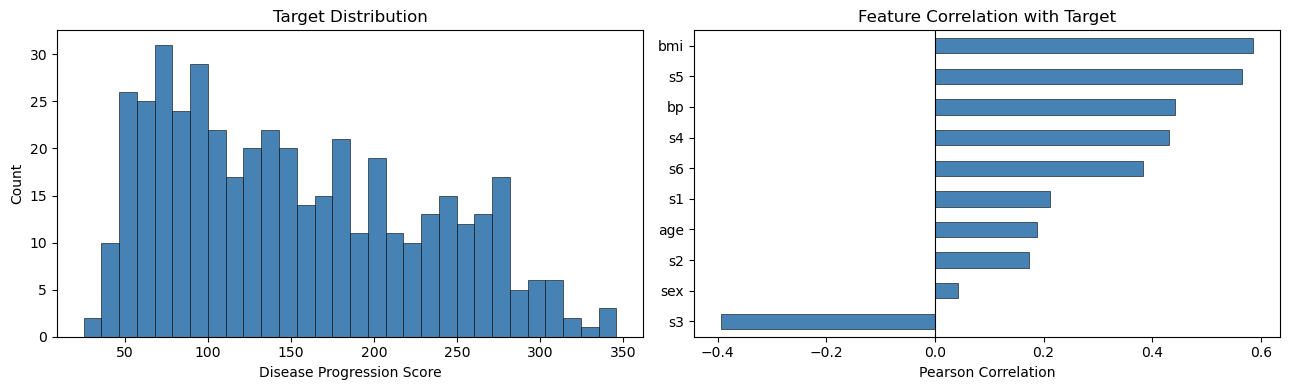

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y, bins=30, color='steelblue', edgecolor='k', linewidth=0.4)
axes[0].set_xlabel('Disease Progression Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution')

corr = df.corr()['target'].drop('target').sort_values()
corr.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='k', linewidth=0.4)
axes[1].axvline(0, color='k', linewidth=0.8)
axes[1].set_title('Feature Correlation with Target')
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

---

## 3. Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')

Train : 353 samples
Test  : 89 samples


---

## 4. Baseline: Single Decision Tree

In [11]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt   = dt.predict(X_test)
r2_dt       = r2_score(y_test, y_pred_dt)
rmse_dt     = mean_squared_error(y_test, y_pred_dt)
r2_train_dt = r2_score(y_train, dt.predict(X_train))

print(f'Decision Tree  —  Train R²: {r2_train_dt:.4f}   Test R²: {r2_dt:.4f}   RMSE: {rmse_dt:.4f}')

Decision Tree  —  Train R²: 1.0000   Test R²: 0.0607   RMSE: 4976.7978


---

## 5. AdaBoost Regressor

### 5.1 Training

We train with `n_estimators=110`, `learning_rate=0.001`, and `loss='square'` — matching the original notebook's configuration. The square loss penalizes larger errors more aggressively than linear loss, which can be beneficial when the target has a wide range.

In [13]:
ada = AdaBoostRegressor(
    n_estimators=110,
    learning_rate=0.001,
    loss='square',
    random_state=42
)

ada.fit(X_train, y_train)

y_pred_ada   = ada.predict(X_test)
r2_ada       = r2_score(y_test, y_pred_ada)
rmse_ada     = mean_squared_error(y_test, y_pred_ada)
r2_train_ada = r2_score(y_train, ada.predict(X_train))

print(f'AdaBoost  —  Train R²: {r2_train_ada:.4f}   Test R²: {r2_ada:.4f}   RMSE: {rmse_ada:.4f}')

AdaBoost  —  Train R²: 0.5813   Test R²: 0.4904   RMSE: 2699.7516


### 5.2 Predicted vs. Actual

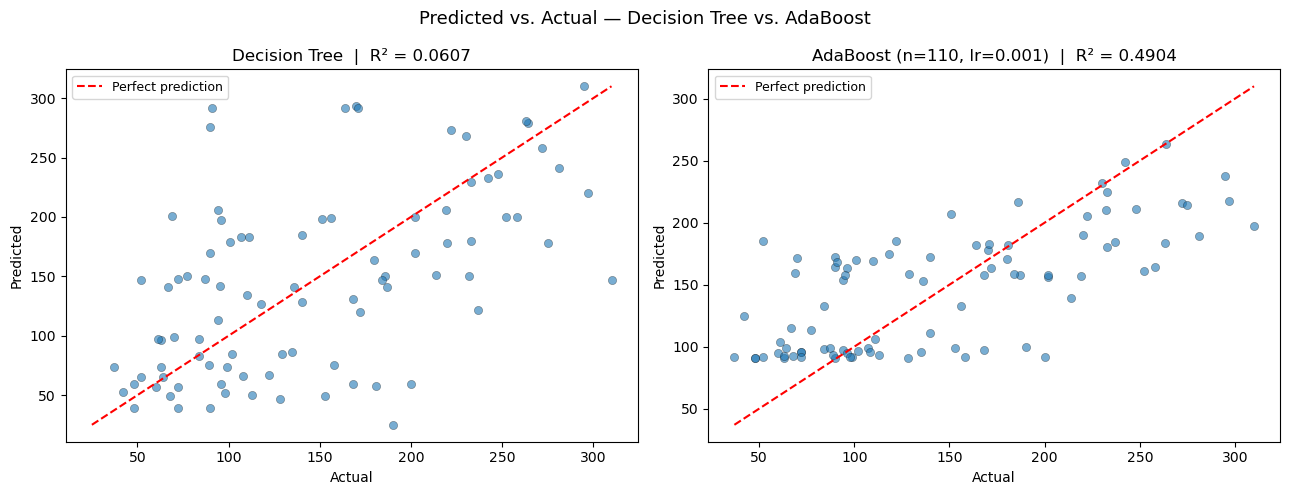

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, r2 in zip(
    axes,
    [y_pred_dt, y_pred_ada],
    ['Decision Tree', 'AdaBoost (n=110, lr=0.001)'],
    [r2_dt, r2_ada]
):
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidths=0.3, s=35)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{title}  |  R² = {r2:.4f}')
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs. Actual — Decision Tree vs. AdaBoost', fontsize=13)
plt.tight_layout()
plt.show()

---

## 6. Effect of n_estimators and Learning Rate

`learning_rate` controls how much each weak learner's contribution is shrunk. A lower rate requires more estimators but often yields better generalization. We compare three rates across a range of `n_estimators`.

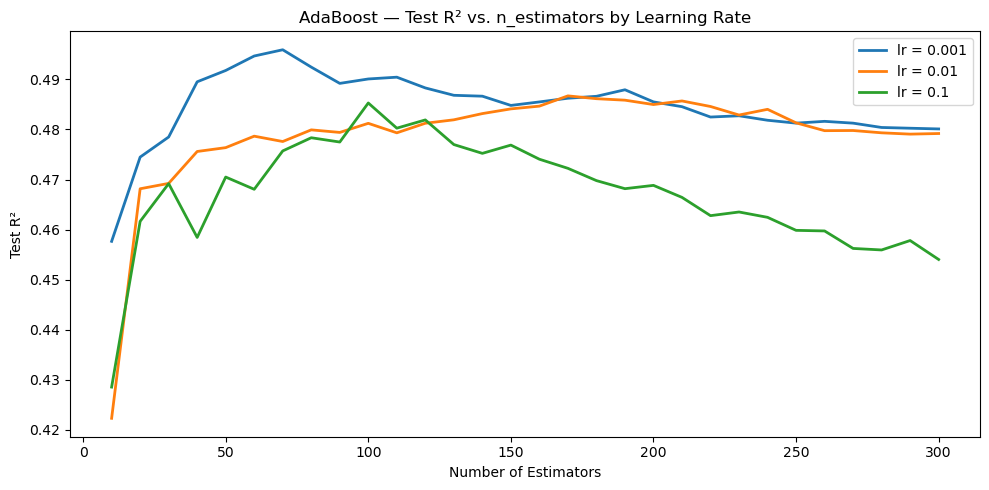

In [18]:
estimator_range = range(10, 301, 10)
learning_rates  = [0.001, 0.01, 0.1]

plt.figure(figsize=(10, 5))

for lr in learning_rates:
    scores = []
    for n in estimator_range:
        model = AdaBoostRegressor(
            n_estimators=n, learning_rate=lr,
            loss='square', random_state=42
        )
        model.fit(X_train, y_train)
        scores.append(r2_score(y_test, model.predict(X_test)))
    plt.plot(estimator_range, scores, lw=2, label=f'lr = {lr}')

plt.xlabel('Number of Estimators')
plt.ylabel('Test R²')
plt.title('AdaBoost — Test R² vs. n_estimators by Learning Rate')
plt.legend()
plt.tight_layout()
plt.show()

---

## 7. Feature Importances

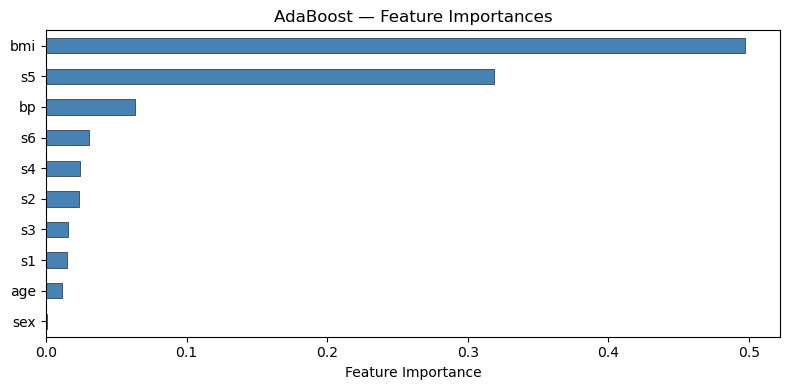


Feature Importances (ranked):
bmi    0.4972
s5     0.3183
bp     0.0637
s6     0.0305
s4     0.0240
s2     0.0237
s3     0.0156
s1     0.0152
age    0.0113
sex    0.0006


In [19]:
importances = pd.Series(
    ada.feature_importances_,
    index=data.feature_names
).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue', edgecolor='k', linewidth=0.4)
plt.xlabel('Feature Importance')
plt.title('AdaBoost — Feature Importances')
plt.tight_layout()
plt.show()

print('\nFeature Importances (ranked):')
print(importances.sort_values(ascending=False).round(4).to_string())

---

## 8. Results Summary

In [20]:
cv_dt  = cross_val_score(DecisionTreeRegressor(random_state=42),
                         X_train, y_train, cv=5, scoring='r2').mean()
cv_ada = cross_val_score(AdaBoostRegressor(
                             n_estimators=110, learning_rate=0.001,
                             loss='square', random_state=42),
                         X_train, y_train, cv=5, scoring='r2').mean()

results = pd.DataFrame({
    'Model':      ['Decision Tree (baseline)', 'AdaBoost (n=110, lr=0.001)'],
    'Train R²':   [round(r2_train_dt, 4), round(r2_train_ada, 4)],
    'Test R²':    [round(r2_dt, 4),       round(r2_ada, 4)],
    'Test RMSE':  [round(rmse_dt, 4),     round(rmse_ada, 4)],
    'CV R²':      [round(cv_dt, 4),       round(cv_ada, 4)]
})

print(results.to_string(index=False))

                     Model  Train R²  Test R²  Test RMSE   CV R²
  Decision Tree (baseline)    1.0000   0.0607  4976.7978 -0.1328
AdaBoost (n=110, lr=0.001)    0.5813   0.4904  2699.7516  0.3956


---

## Conclusion

This notebook applied `AdaBoostRegressor` to the Diabetes dataset using `loss='square'` and a very small `learning_rate=0.001`.

**Key findings:**

- The single **Decision Tree** achieves train R² = 1.0, confirming severe overfitting — it memorizes every training sample but generalizes poorly to unseen data.
- **AdaBoost** reduces the train-test gap significantly by sequentially fitting weak learners to the residuals. The square loss gives more weight to samples with large errors, focusing each round on the most difficult predictions.
- The **learning rate plot** shows that `lr=0.001` converges very slowly — requiring many more estimators than `lr=0.01` or `lr=0.1` to reach peak performance. A rate of `0.01` or `0.1` would likely achieve better R² with fewer trees on this dataset.
- **Feature importances** show `bmi` and `s5` (a serum measurement) as the dominant predictors of disease progression — consistent with their strong Pearson correlations to the target visible in the correlation chart.

**Takeaways:**

- `learning_rate=0.001` is unusually conservative for AdaBoost — unless paired with a very large `n_estimators`, it may underfit. A value between `0.05` and `0.3` is a more practical starting point.
- `loss='square'` is appropriate when large errors should be penalized more than small ones, but it also makes the model more sensitive to outliers in the target.
- The Diabetes dataset is pre-normalized, so no additional scaling is needed — a key advantage of working with sklearn's built-in datasets.
- For structured tabular data like this, **Gradient Boosting** or **XGBoost** typically outperforms `AdaBoostRegressor` due to their more flexible loss functions and built-in regularization.